## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 30)

## 2. Load Data

In [4]:
df = pd.read_csv('C:/Projects/online-retail-rfm-segmentation/data/cleaned_online_retail.csv', parse_dates=['InvoiceDate'])
df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0


In [3]:
df.shape[0]

769890

## 3. Initial Data Quality Check

In [6]:
print(df.dtypes)
print()
print("Nulls per column: ", df.isnull().sum())
print()
duplicate_count = df.duplicated().sum()  #Count duplicates across all columns
print("Full row duplicates ALL: ", duplicate_count)

Invoice                 int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
TotalPrice            float64
dtype: object

Nulls per column:  Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

Full row duplicates ALL:  0


In [10]:
# Convert Invoice to str
df["Invoice"] = df["Invoice"].astype(str)

In [12]:
# Convert Customer ID to str
df["Customer ID"] = df["Customer ID"].astype(str)

In [13]:
print(df.dtypes)

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID               str
Country                   str
TotalPrice            float64
dtype: object


## 4. Calculate RFM (Recency, Frequency, Monetary) metrics for each customer

In [14]:
snapshot_date = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

In [16]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,529,11,372.86
1,12347.0,2,8,4851.48
2,12348.0,75,5,1658.40
3,12349.0,18,3,3678.69
4,12350.0,310,1,294.40


In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,5851.000000,5851.000000,5851.000000
mean,199.852675,6.250385,2855.665399
std,208.566572,12.747812,14022.786042
min,0.000000,1.000000,2.900000
25%,25.000000,1.000000,337.555000
50%,95.000000,3.000000,846.870000
75%,379.000000,7.000000,2218.385000
max,738.000000,375.000000,574997.200000


## 5. Manual RFM scoring (quintiles)

In [18]:
# Recency: lower is better, so labels are reversed (5 = most recent = best)
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])

# Frequency: higher is better, so labels go in normal order
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])

# Monetary: higher is better, normal order
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])   

rfm.head(3)

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346.0,529,11,372.86,1,5,2
1,12347.0,2,8,4851.48,5,4,5
2,12348.0,75,5,1658.40,3,4,4


In [19]:
# Combine into an RFM Score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head(3)

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.0,529,11,372.86,1,5,2,152
1,12347.0,2,8,4851.48,5,4,5,545
2,12348.0,75,5,1658.40,3,4,4,344


In [20]:
# Map to named segments
def segment_customer(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [21]:
rfm.head(3)

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346.0,529,11,372.86,1,5,2,152,At Risk
1,12347.0,2,8,4851.48,5,4,5,545,Champions
2,12348.0,75,5,1658.40,3,4,4,344,Loyal Customers


In [22]:
rfm['Segment'].value_counts()

Segment
Lost               1512
Loyal Customers    1399
Champions          1283
Needs Attention     851
New Customers       447
At Risk             359
Name: count, dtype: int64

## 6. Segment Count Bar Chart

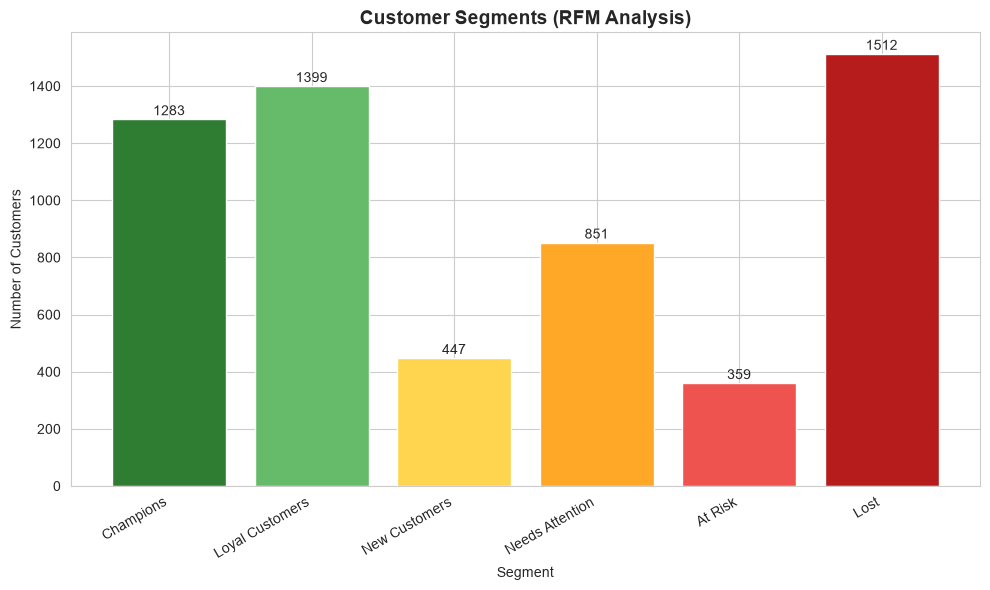

In [25]:
# Define a logical order rather than default alphabetical/frequency sort
segment_order = ['Champions', 'Loyal Customers', 'New Customers', 
                  'Needs Attention', 'At Risk', 'Lost']

segment_colors = ['#2E7D32', '#66BB6A', '#FFD54F', '#FFA726', '#EF5350', '#B71C1C']

segment_counts = rfm['Segment'].value_counts().reindex(segment_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(segment_counts.index, segment_counts.values, color=segment_colors)

plt.title('Customer Segments (RFM Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 15,
    str(int(height)), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Recency vs Frequency Scatter Plot

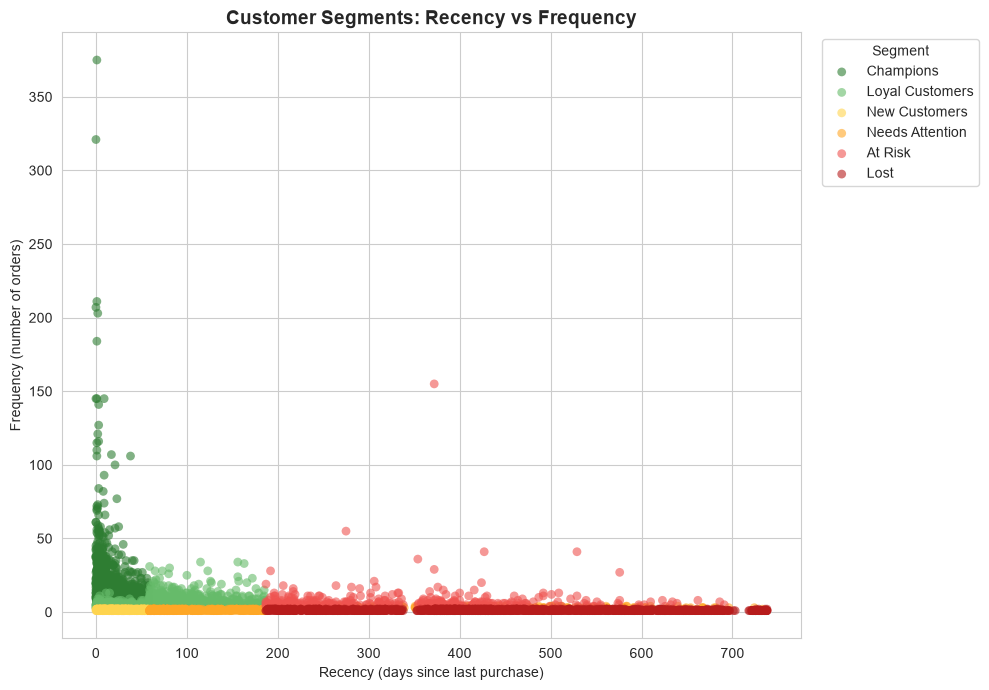

In [33]:
#from matplotlib.ticker import ScalarFormatter

#plt.yscale('log')
#plt.gca().yaxis.set_major_formatter(ScalarFormatter())
#plt.ylabel('Frequency (number of orders)')

segment_order = ['Champions', 'Loyal Customers', 'New Customers', 
                  'Needs Attention', 'At Risk', 'Lost']

segment_colors = {
    'Champions': '#2E7D32',
    'Loyal Customers': '#66BB6A',
    'New Customers': '#FFD54F',
    'Needs Attention': '#FFA726',
    'At Risk': '#EF5350',
    'Lost': '#B71C1C'
}

plt.figure(figsize=(10, 7))

for segment in segment_order:
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Recency'], subset['Frequency'], 
                label=segment, color=segment_colors[segment], 
                alpha=0.6, s=40, edgecolors='none')

plt.title('Customer Segments: Recency vs Frequency', fontsize=14, fontweight='bold')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Frequency (number of orders)')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
#plt.yscale('log')
plt.show()

## 8. Segment profiling table

In [43]:
segment_notes = {
    'Champions': 'Best customers - protect with loyalty perks',
    'Loyal Customers': 'Reliable repeat buyers - upsell opportunity',
    'New Customers': 'Recent first-time buyers - nurture into repeat purchases',
    'Needs Attention': 'Mixed signals - monitor closely',
    'At Risk': 'High-value customers going quiet — high-priority win-back target',
    'Lost': 'Long inactive - low-cost reactivation or deprioritize'
}

segment_profile = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median']).round(1)
segment_profile['Notes'] = segment_profile.index.map(segment_notes)
pd.set_option('display.max_colwidth', 100)
segment_profile

Recency        Frequency        Monetary          \
                   mean median      mean median     mean  median   
Segment                                                            
At Risk           342.2  336.0       7.6    6.0   2865.4  1555.8   
Champions          19.2   16.0      17.0   11.0   9003.3  3879.6   
Lost              456.3  432.0       1.2    1.0    405.7   271.6   
Loyal Customers    70.3   65.0       5.4    4.0   1851.6  1076.8   
Needs Attention   259.9  225.0       2.2    2.0    802.4   558.3   
New Customers      27.5   26.0       1.5    1.0    541.4   363.3   

                                                                            Notes  
                                                                                   
Segment                                                                            
At Risk          High-value customers going quiet — high-priority win-back target  
Champions                             Best customers - protect with loyalty perks  
Lost                        Long inactive - low-cost reactivation or deprioritize  
Loyal Customers                       Reliable repeat buyers - upsell opportunity  
Needs Attention                                   Mixed signals - monitor closely  
New Customers            Recent first-time buyers - nurture into repeat purchases

In [44]:
# Reorder the table
segment_profile = segment_profile.reindex(segment_order)
segment_profile

Recency        Frequency        Monetary          \
                   mean median      mean median     mean  median   
Segment                                                            
Champions          19.2   16.0      17.0   11.0   9003.3  3879.6   
Loyal Customers    70.3   65.0       5.4    4.0   1851.6  1076.8   
New Customers      27.5   26.0       1.5    1.0    541.4   363.3   
Needs Attention   259.9  225.0       2.2    2.0    802.4   558.3   
At Risk           342.2  336.0       7.6    6.0   2865.4  1555.8   
Lost              456.3  432.0       1.2    1.0    405.7   271.6   

                                                                            Notes  
                                                                                   
Segment                                                                            
Champions                             Best customers - protect with loyalty perks  
Loyal Customers                       Reliable repeat buyers - upsell opportunity  
New Customers            Recent first-time buyers - nurture into repeat purchases  
Needs Attention                                   Mixed signals - monitor closely  
At Risk          High-value customers going quiet — high-priority win-back target  
Lost                        Long inactive - low-cost reactivation or deprioritize

## 9. Revenue Concentration

In [35]:
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().reindex(segment_order)
revenue_pct = (revenue_by_segment / revenue_by_segment.sum() * 100).round(1)

for seg, pct in revenue_pct.items():
    print(f"{seg}: {pct}% of total revenue")

Champions: 69.1% of total revenue
Loyal Customers: 15.5% of total revenue
New Customers: 1.4% of total revenue
Needs Attention: 4.1% of total revenue
At Risk: 6.2% of total revenue
Lost: 3.7% of total revenue


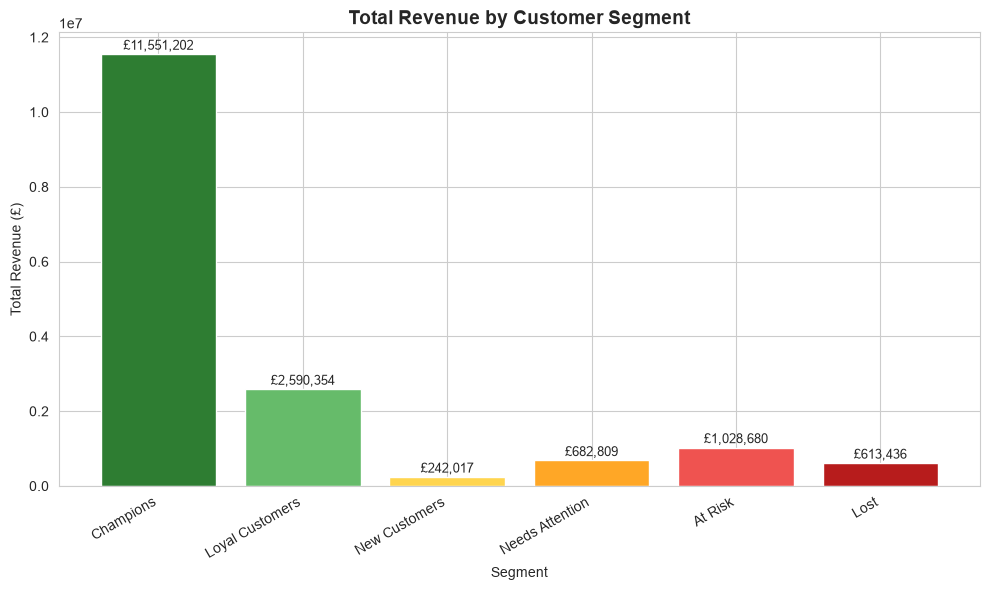

In [36]:
segment_colors_list = [segment_colors[seg] for seg in segment_order]

plt.figure(figsize=(10, 6))
bars = plt.bar(revenue_by_segment.index, revenue_by_segment.values, color=segment_colors_list)

plt.title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=30, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (revenue_by_segment.max()*0.01), 
              f'£{height:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Export RFM data for Power BI

In [45]:
rfm.to_csv('C:/Projects/online-retail-rfm-segmentation/data/rfm_segments.csv', index=False)